#### Загрузка датасета

In [ ]:
!gdown "https://drive.google.com/uc?id=1ZMPIHcEVOZx9OukDOGvmkndkVGYpmIEF" -O seminar_objdet_retina_oi5_ball.zip

Downloading...
From (original): https://drive.google.com/uc?id=1ZMPIHcEVOZx9OukDOGvmkndkVGYpmIEF
From (redirected): https://drive.google.com/uc?id=1ZMPIHcEVOZx9OukDOGvmkndkVGYpmIEF&confirm=t&uuid=b7215fbb-3c36-4fc9-b140-77148ee19f52
To: /content/seminar_objdet_retina_oi5_ball.zip
100% 1.08G/1.08G [00:05<00:00, 189MB/s]


In [ ]:
from zipfile import ZipFile

with ZipFile('seminar_objdet_retina_oi5_ball.zip', 'r') as zip_data:
    zip_data.extractall('unzip_data')

#### Дообучение сети

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models.detection import SSDLite320_MobileNet_V3_Large_Weights, ssdlite320_mobilenet_v3_large, ssdlite, ssd, ssd300_vgg16, SSD300_VGG16_Weights
from torch.utils.data import Dataset, DataLoader
import gc
from torchmetrics.detection import MeanAveragePrecision
from pathlib import Path
import json
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:

resize_transform = transforms.Compose([transforms.Resize(250, max_size = 300)])

# Цветовые преобразования (аугментации, не затрагивающие bounding boxes с различными вероятностями применения)
transform = transforms.Compose([transforms.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.2, hue=0.1)])

class BallDetectionDataset(Dataset):
    def __init__(self, images_dir, annotations_file, transform=None):

        #Аргументы:
            #images_dir (str): Путь к папке с изображениями
            #annotations_file (str): Путь к JSON файлу с аннотациями
            #transform: Аугментации/трансформации для изображений
        self.images_dir = Path(images_dir)
        self.annotations_file = annotations_file
        self.transform = transform

        with open(annotations_file, 'r') as f:
            self.annotations = json.load(f)

        # Создание списка валидных изображений и их размеры
        self.samples = []
        for img_file in self.annotations.keys():
            img_path = self.images_dir / img_file
            if img_path.exists():
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        #print(img_path)
                        self.samples.append({'file': img_file, 'path': img_path, 'width': width, 'height': height})
                except Exception as e:
                    print(f"Error loading {img_file}: {e}")

        self.samples = sorted(self.samples, key=lambda x: (x['width']**2 + x['height']**2)**0.5)


    def __len__(self):
        return len(self.samples)

    def convert_to_ssd_format(self, bboxes_info, original_width, original_height):
        """
        Конвертирует аннотации в SSD формат
        """
        boxes = []
        for bbox in bboxes_info:
            x1_norm, x2_norm, y1_norm, y2_norm = bbox[:4]

            x1 = x1_norm*original_width
            x2 = x2_norm*original_width
            y1 = y1_norm*original_height
            y2 = y2_norm*original_height
            # Класс (все объекты - мячи, class_id = 0)
            class_id = 1
            boxes.append([x1, y1, x2, y2])

        return {'boxes': torch.tensor(boxes, dtype=torch.float32), 'labels': torch.tensor([class_id]*len(boxes), dtype=torch.int64)}

    def __getitem__(self, idx):
        #информация о sample
        sample_info = self.samples[idx]
        img_path = sample_info['path']
        # изображение
        image = Image.open(img_path).convert('RGB')
        # применение трансформации (если есть)
        if self.transform:
            image = self.transform(image)

        image_np = np.array(image)
        original_width, original_height = image.size
        # аннотации для изображения
        bboxes_info = self.annotations[sample_info['file']]
        # реобразование аннотации в формат SSD
        ssd_annotations  = self.convert_to_ssd_format(bboxes_info, original_width, original_height)
        image_processed = resize_transform(torch.from_numpy(image_np).permute(2, 0, 1).float()/255)
        _, new_height, new_width,  = image_processed.shape

        for box in ssd_annotations['boxes']:
            box[1]*= new_width/original_width
            box[3]*= new_width/original_width
            box[0]*= new_height/original_height
            box[2]*= new_height/original_height


        return image_processed, ssd_annotations

In [ ]:
def collate_fn(batch):
    """
    Collate function которая:
    1. Находит максимальные H и W в батче
    2. Дополняет все изображения до максимального размера
    3. Корректирует bbox'ы относительно новых координат
    """
    images = []
    targets = []

    # Собираем все изображения и таргеты
    for sample in batch:
        images.append(sample[0])
        targets.append(sample[1])

    # Находим максимальные размеры в батче
    max_height = max([img.shape[1] for img in images])
    max_width = max([img.shape[2] for img in images])

    padded_images = []
    adjusted_targets = []

    for i, (image, target) in enumerate(zip(images, targets)):
        # Получаем размеры текущего изображения
        _, h, w = image.shape

        # Вычисляем паддинг
        pad_bottom = (max_height - h)//2
        pad_right = (max_width - w)//2
        pad_left = (max_width - w)//2 + ((max_width - w)%2)
        pad_top = (max_height - h)//2 + ((max_height - h)%2)

        # Добавляем паддинг (сверху и слева 0, снизу и справа вычисленные)
        padded_image = F.pad(image, (pad_left, pad_right, pad_top, pad_bottom), value=0)
        padded_images.append(padded_image)

        # Копируем таргет
        adjusted_target = {}
        for key in target:
            if key == 'boxes':
                adjusted_target['boxes'] = torch.tensor([[box[0]+pad_left, box[1] + pad_top, box[2] + pad_left, box[3]+ pad_top] for box  in target[key]], dtype=torch.float32)

            else:
                adjusted_target[key] = target[key].clone()

        adjusted_targets.append(adjusted_target)

    # Собираем в батч
    batch_tensor = torch.stack(padded_images, dim=0)
    return batch_tensor, adjusted_targets



In [ ]:
IMAGES_DIR = 'unzip_data/seminar_objdet_retina_oi5_ball'
ANNOTATIONS_FILE_TRAIN = "unzip_data/seminar_objdet_retina_oi5_ball/oi5_ball_filename_to_bbox_train.json"

with open(ANNOTATIONS_FILE_TRAIN, 'r') as f:
    annotations = json.load(f)
print(f"Must be loaded {len(annotations.keys())} train images")

dataset_train = BallDetectionDataset(images_dir=IMAGES_DIR, annotations_file=ANNOTATIONS_FILE_TRAIN, transform = transform)
print(f"Loaded {len(dataset_train)} train images")
print("="*35)

ANNOTATIONS_FILE_TEST = "unzip_data/seminar_objdet_retina_oi5_ball/oi5_ball_filename_to_bbox_val.json"
with open(ANNOTATIONS_FILE_TEST, 'r') as f:
    annotations = json.load(f)
print(f"Must be loaded {len(annotations.keys())} test images")

dataset_test = BallDetectionDataset(images_dir=IMAGES_DIR, annotations_file=ANNOTATIONS_FILE_TEST)
print(f"Loaded {len(dataset_test)} test images")

Must be loaded 2875 train images
Loaded 2875 train images
Must be loaded 226 test images
Loaded 226 test images


In [ ]:
Loader_train = DataLoader(dataset_train, batch_size=10, shuffle=True, collate_fn = collate_fn)
Loader_test = DataLoader(dataset_test, batch_size=10, shuffle=True, collate_fn = collate_fn)

torch.Size([3, 300, 300])


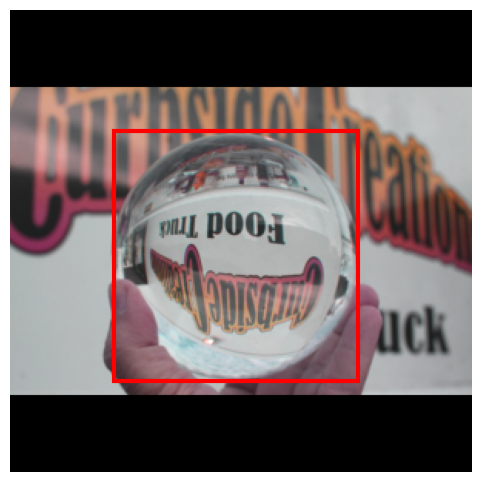

torch.Size([3, 300, 300])


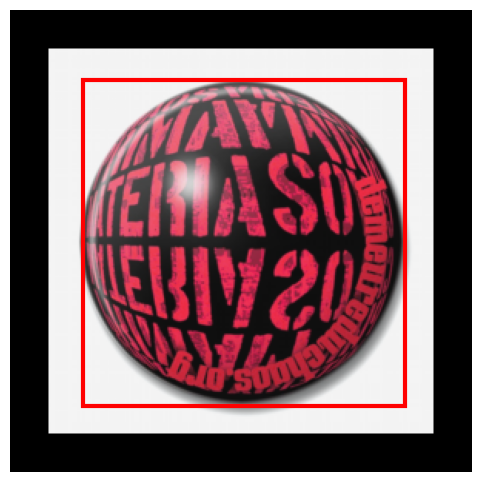

torch.Size([3, 300, 300])


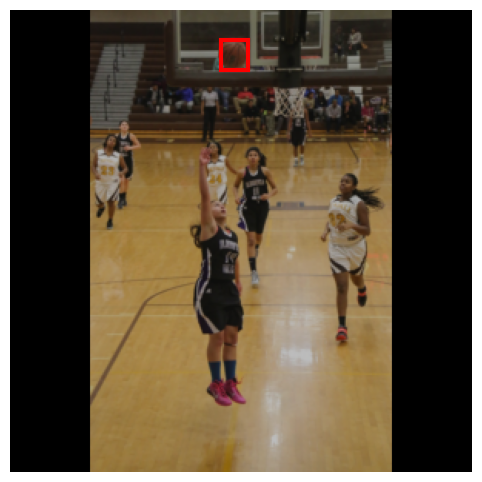

torch.Size([3, 300, 300])


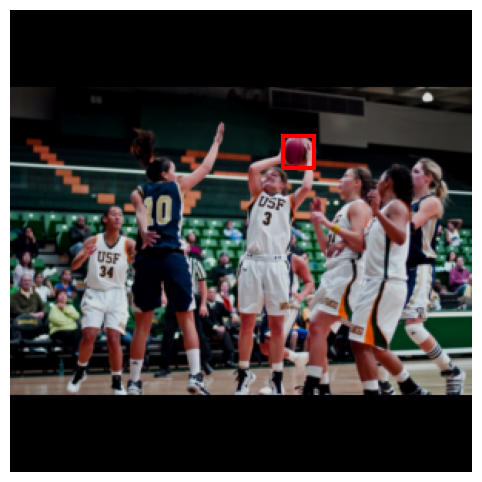

torch.Size([3, 300, 300])


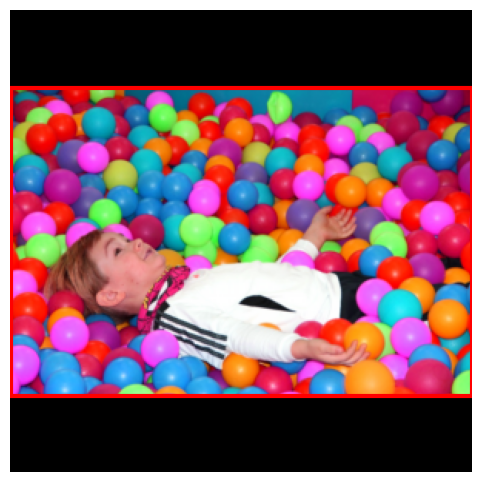

torch.Size([3, 300, 300])


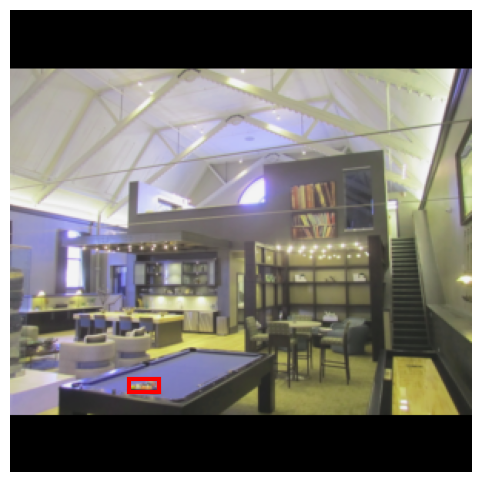

torch.Size([3, 300, 300])


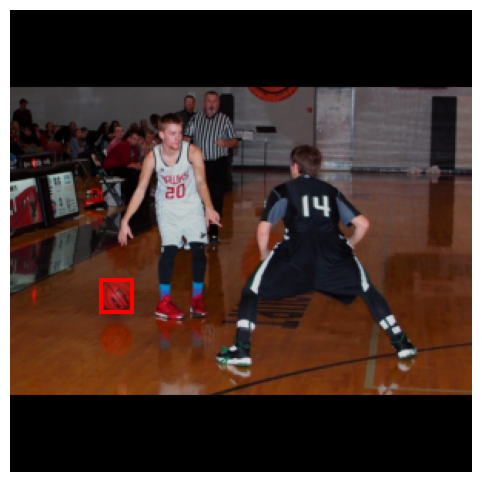

torch.Size([3, 300, 300])


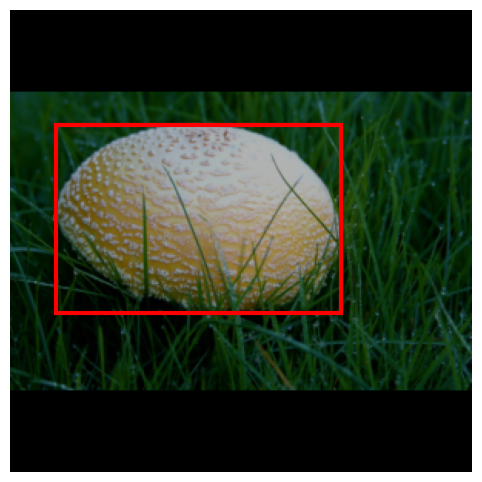

torch.Size([3, 300, 300])


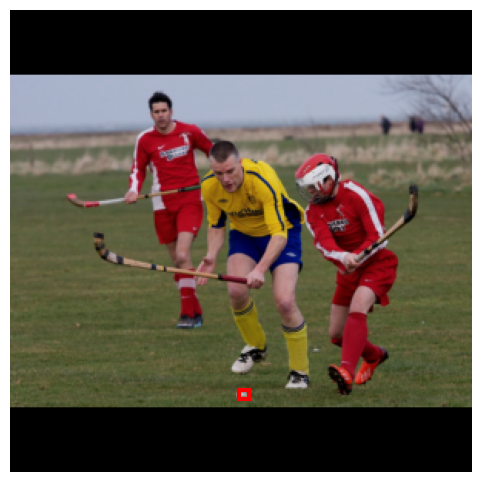

torch.Size([3, 300, 300])


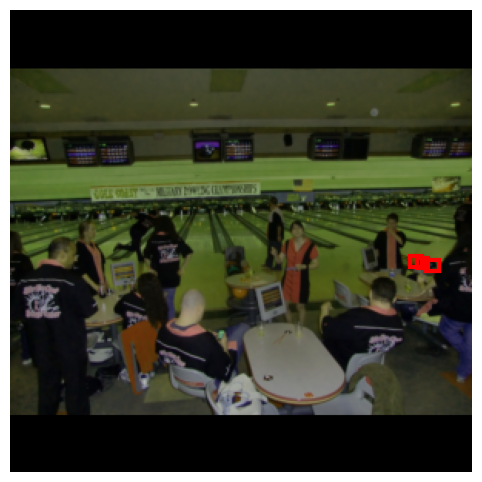

In [ ]:

# Вывод одного из батчей и соответстующих таргетов-прямоугольников (чтобы убедиться, что все манипуляции с данными прошли нормально)
for im in Loader_train:
    X = im[0]
    Y = im[1]
    break

for x,y in zip(X,Y):
    print(x.shape)
    x = x.permute(1, 2, 0).numpy()
    x = (x*255).astype('uint8')
    rectangles = y['boxes'].numpy()

    fig, ax = plt.subplots(1,1, figsize = (8, 6))
    ax.imshow(x)
    for rect in rectangles:
        ax.add_patch(plt.Rectangle((rect[0], rect[1]), rect[2]-rect[0], rect[3]-rect[1], linewidth = 3, edgecolor = 'red', facecolor = 'none'))

    plt.axis('off')
    plt.show()

In [ ]:


def create_ssd_single_class(model):
    """
    Создает SSD модель с одним классом (не включая background)
    Фактически будет 2 класса: background + наш класс
    """
    old_classifier = model.head.classification_head
    num_anchors = model.anchor_generator.num_anchors_per_location()
    # Создаем новую голову классификации для 2 классов (background + 1 класс)
    in_channels = [old_classifier.module_list[i].in_channels for i in range(len(old_classifier.module_list))]
    model.head.classification_head = ssd.SSDClassificationHead(in_channels=in_channels, num_anchors=num_anchors, num_classes=2)

    # веса новой головы
    for layer in model.head.classification_head.modules():
        if isinstance(layer, nn.Conv2d):
            torch.nn.init.normal_(layer.weight, std=0.01)

    return model


def train_layers(model, num_epochs=8, device='cuda'):

    model.to(device)
    train_losses = []
    mAP = []
    for param in model.parameters():
        param.requires_grad = True
    """
    #с заморозкой слоёв mAP на валидации ниже
    backbone = model.backbone
    layers = list(backbone.children())

    for i in range(len(layers)):
        for param in layers[i].parameters():
            #param.requires_grad = False
    """
    backbone_params =[]
    other_params = []
    for name, param in model.named_parameters():
      if "bacbone" in name:
        backbone_params.append(param)
      else:
        other_params.append(param)

    #torch.cuda.empty_cache()
    optimizer = torch.optim.AdamW([{"params": backbone_params, "lr": 5e-5},{"params": other_params, "lr": 1e-4}], betas = (0.6, 0.5), eps = 1e-7, weight_decay = 1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.2)
    metric = MeanAveragePrecision()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch_idx, im_and_targ in enumerate(Loader_train):
            images = im_and_targ[0].to(device)
            targets = [{"boxes": label["boxes"].to(device), "labels":label["labels"].to(device)} for label in im_and_targ[1]]
            #print(batch_idx)
            optimizer.zero_grad()
            # Прямой проход и вычисление потерь
            loss_dict = model(images,targets)
            losses = sum(x for x in loss_dict.values())

            losses.backward()
            optimizer.step()

            #images.to("cpu")
            #targets = [{"boxes": label["boxes"].to("cpu"), "labels":label["labels"].to("cpu")} for label in targets]

            total_loss += loss_dict['bbox_regression'].item()
            loss_reg = loss_dict['bbox_regression'].item()
            if batch_idx % 10 == 0:
                print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss_reg:.4f}')
                #print(torch.cuda.memory_allocated()/1024**3,"GB") #отслеживание кэша на предмет прееплнения

            #чистка памяти (пару раз до неё кэш преполнился)
            for loss in loss_dict.values():
              del loss
            del images
            for targ in targets:
              for t in targ.values():
                del t
            gc.collect()
            torch.cuda.empty_cache()


        # Validation
        model.eval()
        with torch.no_grad():
          preds, targets = [], []
          for batch_idx, im_and_targ in enumerate(Loader_test):

              images = im_and_targ[0].to(device)
              target = [{"boxes": label["boxes"].to(device), "labels":label["labels"].to(device)} for label in im_and_targ[1]]
              preds.extend(model(images))
              #images.to("cpu")
              #targets = [{"boxes": label["boxes"].to("cpu"), "labels":label["labels"].to("cpu")} for label in targets]
              targets.extend(target)

              del images
              for targ in targets:
                for t in targ.values():
                  del t
              gc.collect()
              torch.cuda.empty_cache()

          metric.update(preds, targets)
          results = metric.compute()

          for pred in preds:
            del pred
          gc.collect()
          torch.cuda.empty_cache()

          train_losses.append(total_loss / len(Loader_train))
          mAP.append(results["map_50"])

          print(f'Epoch {epoch+1}/{num_epochs}:')
          print(f'  Train Loss: {(total_loss / len(Loader_train)):.4f}')
          print(f"  Val mAP: {results['map']:.4f}")
          print(f"  Val mAP@0.5: {results['map_50']:.4f}")
          print(f"  Val mAP@0.75: {results['map_75']:.4f}")
          scheduler.step()

    return train_losses, mAP
        #print(f'  LR: {scheduler.get_last_lr()[0]:.6f}')


In [ ]:
#Предобученная модель
weights=SSD300_VGG16_Weights.DEFAULT
model = ssd300_vgg16(weights=weights, progress = True) # замена головы модели (на одноклассовую)

model = create_ssd_single_class(model) # замена головы модели (на одноклассовую)

In [ ]:

predlern_loss_train, mAP_test_predlearn = train_layers(model)#, device = "cpu")

Epoch: 0, Batch: 0, Loss: 1.1452
Epoch: 0, Batch: 10, Loss: 0.7829
Epoch: 0, Batch: 20, Loss: 0.8157
Epoch: 0, Batch: 30, Loss: 0.9137
Epoch: 0, Batch: 40, Loss: 1.3629
Epoch: 0, Batch: 50, Loss: 1.0388
Epoch: 0, Batch: 60, Loss: 0.5614
Epoch: 0, Batch: 70, Loss: 0.5567
Epoch: 0, Batch: 80, Loss: 0.9151
Epoch: 0, Batch: 90, Loss: 0.4171
Epoch: 0, Batch: 100, Loss: 0.6340
Epoch: 0, Batch: 110, Loss: 0.9583
Epoch: 0, Batch: 120, Loss: 0.3226
Epoch: 0, Batch: 130, Loss: 0.5537
Epoch: 0, Batch: 140, Loss: 0.8460
Epoch: 0, Batch: 150, Loss: 0.9067
Epoch: 0, Batch: 160, Loss: 0.9348
Epoch: 0, Batch: 170, Loss: 0.7156
Epoch: 0, Batch: 180, Loss: 0.5217
Epoch: 0, Batch: 190, Loss: 0.7042
Epoch: 0, Batch: 200, Loss: 1.1635
Epoch: 0, Batch: 210, Loss: 1.1299
Epoch: 0, Batch: 220, Loss: 0.3020
Epoch: 0, Batch: 230, Loss: 1.4566
Epoch: 0, Batch: 240, Loss: 1.0099
Epoch: 0, Batch: 250, Loss: 0.8570
Epoch: 0, Batch: 260, Loss: 0.7458
Epoch: 0, Batch: 270, Loss: 1.0122
Epoch: 0, Batch: 280, Loss: 0.4

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Epoch 1/8:
  Train Loss: 0.7719
  Val mAP: 0.2990
  Val mAP@0.5: 0.5056
  Val mAP@0.75: 0.3289
Epoch: 1, Batch: 0, Loss: 0.5380
Epoch: 1, Batch: 10, Loss: 0.6655
Epoch: 1, Batch: 20, Loss: 0.2221
Epoch: 1, Batch: 30, Loss: 0.3487
Epoch: 1, Batch: 40, Loss: 0.5514
Epoch: 1, Batch: 50, Loss: 0.9041
Epoch: 1, Batch: 60, Loss: 0.6489
Epoch: 1, Batch: 70, Loss: 0.8443
Epoch: 1, Batch: 80, Loss: 1.0437
Epoch: 1, Batch: 90, Loss: 0.6976
Epoch: 1, Batch: 100, Loss: 0.8125
Epoch: 1, Batch: 110, Loss: 0.3147
Epoch: 1, Batch: 120, Loss: 0.5147
Epoch: 1, Batch: 130, Loss: 0.5397
Epoch: 1, Batch: 140, Loss: 0.2970
Epoch: 1, Batch: 150, Loss: 0.3348
Epoch: 1, Batch: 160, Loss: 0.8556
Epoch: 1, Batch: 170, Loss: 0.8979
Epoch: 1, Batch: 180, Loss: 0.3512
Epoch: 1, Batch: 190, Loss: 0.8185
Epoch: 1, Batch: 200, Loss: 1.3861
Epoch: 1, Batch: 210, Loss: 0.5377
Epoch: 1, Batch: 220, Loss: 0.7236
Epoch: 1, Batch: 230, Loss: 1.0519
Epoch: 1, Batch: 240, Loss: 0.5758
Epoch: 1, Batch: 250, Loss: 0.4027
Epoch:

In [ ]:
# непредобученная модель
model = ssd300_vgg16(progress = True) # замена головы модели (на одноклассовую)
model = create_ssd_single_class(model) # замена головы модели (на одноклассовую)
loss_train, mAP_test = train_layers(model)#, device = "cpu")

Downloading: "https://download.pytorch.org/models/vgg16_features-amdegroot-88682ab5.pth" to /root/.cache/torch/hub/checkpoints/vgg16_features-amdegroot-88682ab5.pth


100%|██████████| 528M/528M [00:06<00:00, 79.8MB/s]


Epoch: 0, Batch: 0, Loss: 15.1050
Epoch: 0, Batch: 10, Loss: 2.6281
Epoch: 0, Batch: 20, Loss: 3.8101
Epoch: 0, Batch: 30, Loss: 4.9136
Epoch: 0, Batch: 40, Loss: 2.8783
Epoch: 0, Batch: 50, Loss: 2.3186
Epoch: 0, Batch: 60, Loss: 1.7520
Epoch: 0, Batch: 70, Loss: 1.7196
Epoch: 0, Batch: 80, Loss: 2.1034
Epoch: 0, Batch: 90, Loss: 2.2214
Epoch: 0, Batch: 100, Loss: 2.7030
Epoch: 0, Batch: 110, Loss: 2.2716
Epoch: 0, Batch: 120, Loss: 2.0926
Epoch: 0, Batch: 130, Loss: 1.8666
Epoch: 0, Batch: 140, Loss: 1.8490
Epoch: 0, Batch: 150, Loss: 1.9970
Epoch: 0, Batch: 160, Loss: 1.9137
Epoch: 0, Batch: 170, Loss: 1.8015
Epoch: 0, Batch: 180, Loss: 2.1098
Epoch: 0, Batch: 190, Loss: 2.1121
Epoch: 0, Batch: 200, Loss: 2.0524
Epoch: 0, Batch: 210, Loss: 2.1485
Epoch: 0, Batch: 220, Loss: 1.7795
Epoch: 0, Batch: 230, Loss: 1.3928
Epoch: 0, Batch: 240, Loss: 1.5612
Epoch: 0, Batch: 250, Loss: 2.2869
Epoch: 0, Batch: 260, Loss: 1.9031
Epoch: 0, Batch: 270, Loss: 1.8880
Epoch: 0, Batch: 280, Loss: 1.

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Epoch 1/8:
  Train Loss: 2.3057
  Val mAP: 0.1242
  Val mAP@0.5: 0.2449
  Val mAP@0.75: 0.1184
Epoch: 1, Batch: 0, Loss: 1.8056
Epoch: 1, Batch: 10, Loss: 2.8474
Epoch: 1, Batch: 20, Loss: 2.1429
Epoch: 1, Batch: 30, Loss: 1.6650
Epoch: 1, Batch: 40, Loss: 1.4434
Epoch: 1, Batch: 50, Loss: 2.0210
Epoch: 1, Batch: 60, Loss: 1.7519
Epoch: 1, Batch: 70, Loss: 1.1704
Epoch: 1, Batch: 80, Loss: 1.6179
Epoch: 1, Batch: 90, Loss: 1.1685
Epoch: 1, Batch: 100, Loss: 1.3711
Epoch: 1, Batch: 110, Loss: 1.3777
Epoch: 1, Batch: 120, Loss: 1.5037
Epoch: 1, Batch: 130, Loss: 2.2394
Epoch: 1, Batch: 140, Loss: 1.2224
Epoch: 1, Batch: 150, Loss: 1.8812
Epoch: 1, Batch: 160, Loss: 1.1338
Epoch: 1, Batch: 170, Loss: 1.8875
Epoch: 1, Batch: 180, Loss: 1.2886
Epoch: 1, Batch: 190, Loss: 2.0574
Epoch: 1, Batch: 200, Loss: 2.5740
Epoch: 1, Batch: 210, Loss: 2.0476
Epoch: 1, Batch: 220, Loss: 0.6369
Epoch: 1, Batch: 230, Loss: 2.3037
Epoch: 1, Batch: 240, Loss: 1.4145
Epoch: 1, Batch: 250, Loss: 1.7069
Epoch:

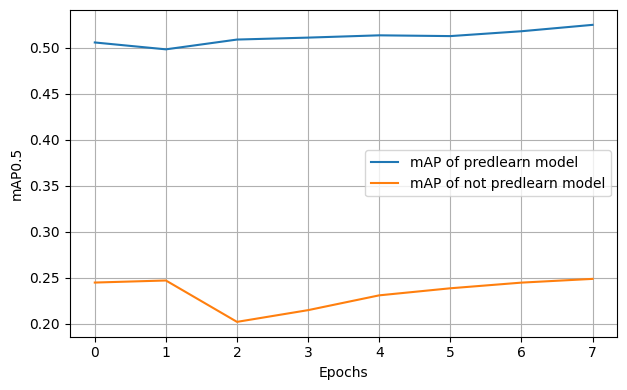

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(mAP_test_predlearn, label ="mAP of predlearn model")
plt.plot(mAP_test, label ="mAP of not predlearn model")
plt.xlabel("Epochs")
plt.ylabel("mAP0.5")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Вывод: предобученная модель показывает лучшее качество в плане метрики mAP (на график вывести её забыл, но на выводах результатов тоже явно видно)  и mAP0.5 на валидации ввиду изначально лучше настроенных значений весов